In [1]:
import numpy as np

def return_x_y(dataset_name):
    if dataset_name  == "sarcos":
        data_train = np.load("../array_data/sarcos/sarcos_inv.npz", allow_pickle=True)
        data_test = np.load("../array_data/sarcos/sarcos_inv_test.npz", allow_pickle=True)
        X_train = data_train['x']
        y_train = data_train['y']
        X_test = data_test['x']
        y_test = data_test['y']
        return X_train, X_test, y_train, y_test
    arr = np.load(f"../array_data/{dataset_name}/{dataset_name}.npz", allow_pickle=True)

    return arr["x"], arr["y"], None, None

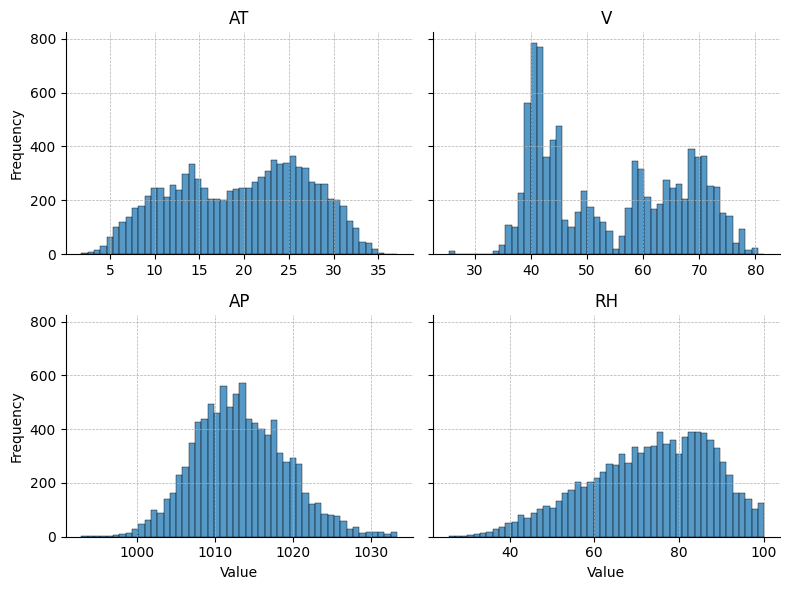

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

x_ccpp, y_ccpp, _, _ = return_x_y("ccpp")

fig, ax = plt.subplots(nrows=2, ncols=2, sharey=True)
sns.histplot(data=x_ccpp[:,0], bins=50, ax=ax[0,0])
ax[0,0].grid(linestyle="--", linewidth=0.5)
ax[0,0].set_ylabel("Frequency")
ax[0,0].set_title("AT")

sns.histplot(data=x_ccpp[:,1], bins=50, ax=ax[0,1])
ax[0,1].grid(linestyle="--", linewidth=0.5)
ax[0,1].set_title("V")


sns.histplot(data=x_ccpp[:,2], bins=50, ax=ax[1,0])
ax[1,0].grid(linestyle="--", linewidth=0.5)
ax[1,0].set_ylabel("Frequency")
ax[1,0].set_xlabel("Value")
ax[1,0].set_title("AP")

sns.histplot(data=x_ccpp[:,3], bins=50, ax=ax[1,1])
ax[1,1].grid(linestyle="--", linewidth=0.5)
ax[1,1].set_xlabel("Value")
ax[1,1].set_title("RH")
#fig.suptitle("Input variables distribution (CCPP dataset)")
fig.set_size_inches((8,6))
for axes in ax.flat:
    axes.spines["top"].set_visible(False)
    axes.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()
fig.savefig("../definitive_plots/ccpp_input_hist.pdf")

In [3]:
np.concatenate((x_ccpp, y_ccpp), axis=1)

array([[  14.96,   41.76, 1024.07,   73.17,  463.26],
       [  25.18,   62.96, 1020.04,   59.08,  444.37],
       [   5.11,   39.4 , 1012.16,   92.14,  488.56],
       ...,
       [  31.32,   74.33, 1012.92,   36.48,  429.57],
       [  24.48,   69.45, 1013.86,   62.39,  435.74],
       [  21.6 ,   62.52, 1017.23,   67.87,  453.28]],
      shape=(9568, 5), dtype=float32)

In [4]:
import pandas as pd
df_ccpp = pd.DataFrame(np.concatenate((x_ccpp, y_ccpp), axis=1), columns=["AT", "V", "AP", "RH", "EP"])
latex = df_ccpp.describe().T[["mean", "std", "min", "max", "25%","50%","75%"]].round(2).to_latex(caption="Statistical Summary inputs CCPP dataset", 
                                                                                           label="tab:stats_ccpp", index=True, float_format="%.2f",
                                                                                           bold_rows=True, escape=True)
print(latex)

\begin{table}
\caption{Statistical Summary inputs CCPP dataset}
\label{tab:stats_ccpp}
\begin{tabular}{lrrrrrrr}
\toprule
 & mean & std & min & max & 25\% & 50\% & 75\% \\
\midrule
\textbf{AT} & 19.65 & 7.45 & 1.81 & 37.11 & 13.51 & 20.35 & 25.72 \\
\textbf{V} & 54.31 & 12.71 & 25.36 & 81.56 & 41.74 & 52.08 & 66.54 \\
\textbf{AP} & 1013.26 & 5.94 & 992.89 & 1033.30 & 1009.10 & 1012.94 & 1017.26 \\
\textbf{RH} & 73.31 & 14.60 & 25.56 & 100.16 & 63.33 & 74.98 & 84.83 \\
\textbf{EP} & 454.37 & 17.07 & 420.26 & 495.76 & 439.75 & 451.55 & 468.43 \\
\bottomrule
\end{tabular}
\end{table}



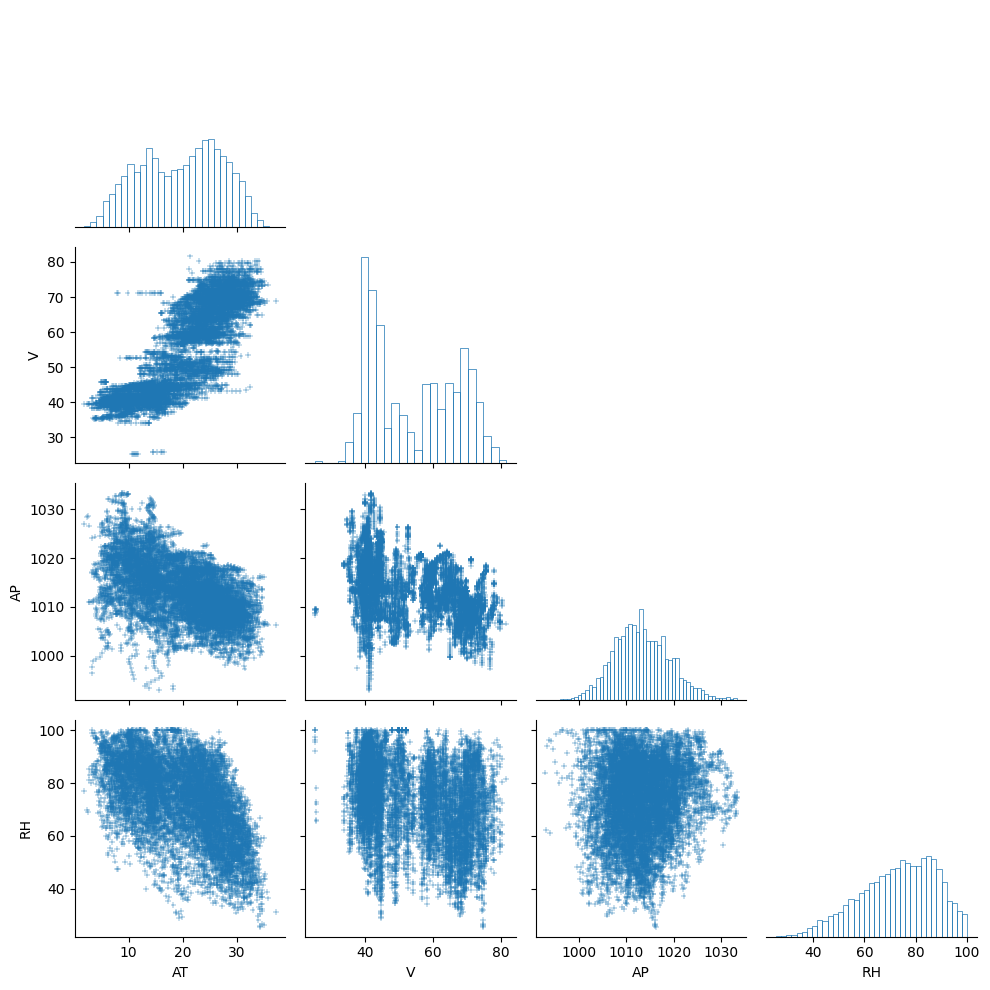

In [5]:
import pandas as pd
df = pd.DataFrame(x_ccpp, columns=["AT", "V", "AP", "RH"])
sns.pairplot(df.assign(Target="y_ccpp"), plot_kws=dict(marker="+", size=0.4), diag_kws=dict(fill=False), corner=True)
plt.savefig("../definitive_plots/pair_plot_ccpp.pdf")
plt.tight_layout()
plt.show()

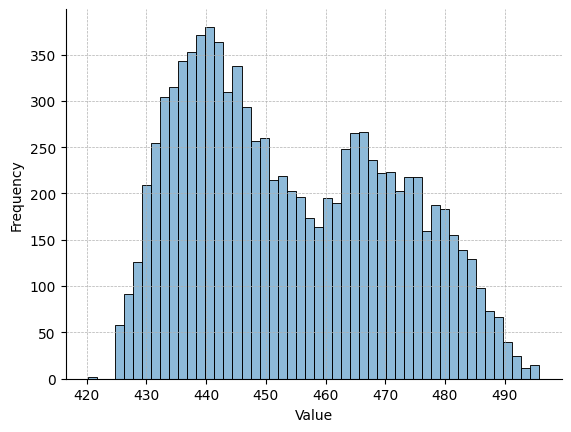

In [6]:
fig, ax = plt.subplots(ncols=1,nrows=1)
sns.histplot(y_ccpp, bins=50, ax=ax, legend=False)
ax.grid(linestyle="--", linewidth=0.5)
ax.grid(linestyle="--", linewidth=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylabel("Frequency")
ax.set_xlabel("Value")
#ax.set_title("Output distribution (CCPP dataset)")
fig.savefig("../definitive_plots/ccpp_dist_y.pdf")

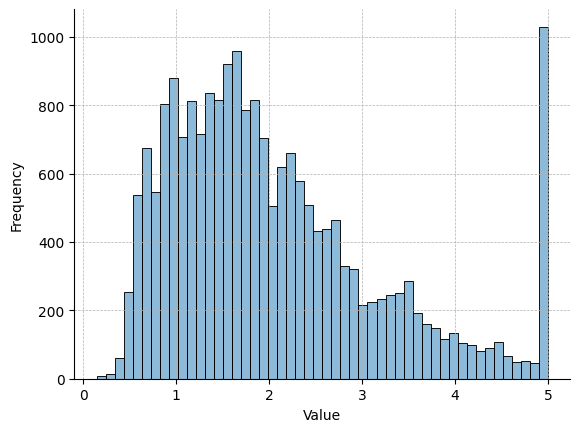

In [7]:
x_housing, y_housing, _, _ = return_x_y("housing")
fig, ax = plt.subplots(ncols=1,nrows=1)
sns.histplot(y_housing, bins=50, ax=ax, legend=False)
ax.grid(linestyle="--", linewidth=0.5)
ax.grid(linestyle="--", linewidth=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylabel("Frequency")
ax.set_xlabel("Value")
#ax.set_title("Output distribution (California Housing dataset)")
fig.savefig("../definitive_plots/housing_dist_y.pdf")

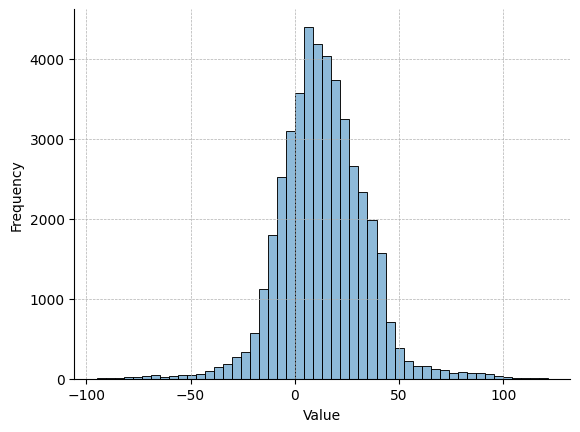

In [8]:
x_sarcos, x_test_sarcos, y_sarcos, y_test_sarcos = return_x_y("sarcos")
fig, ax = plt.subplots(ncols=1,nrows=1)
sns.histplot(y_sarcos, bins=50, ax=ax, legend=False)
ax.grid(linestyle="--", linewidth=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylabel("Frequency")
ax.set_xlabel("Value")
#ax.set_title("Output distribution train (SARCOS dataset)")
fig.savefig("../definitive_plots/sarcos_dist_y.pdf")

In [9]:
sarcos_output_df = pd.DataFrame(data=y_sarcos)
sarcos_output_test_df = pd.DataFrame(data=y_test_sarcos)

desc = sarcos_output_df.describe().T[["mean", "std", "min", "max", "25%","50%","75%"]].round(2)
desc_test = sarcos_output_test_df.describe().T[["mean", "std", "min", "max", "25%","50%","75%"]].round(2)

In [10]:
# Agregar una columna para identificar el conjunto
desc["Dataset"] = "Train"
desc_test["Dataset"] = "Test"

# Unir verticalmente
combined = pd.concat([desc, desc_test], axis=0)

# Reordenar columnas para que Dataset sea la primera
cols = ["Dataset"] + [c for c in combined.columns if c != "Dataset"]
combined = combined[cols]

# Imprimir en LaTeX
print(combined.to_latex(index=False))

\begin{tabular}{lrrrrrrr}
\toprule
Dataset & mean & std & min & max & 25% & 50% & 75% \\
\midrule
Train & 13.650000 & 20.460000 & -94.880000 & 121.380000 & 1.090000 & 12.810000 & 25.830000 \\
Test & 13.690000 & 20.350000 & -84.680000 & 120.970000 & 1.310000 & 13.050000 & 25.830000 \\
\bottomrule
\end{tabular}



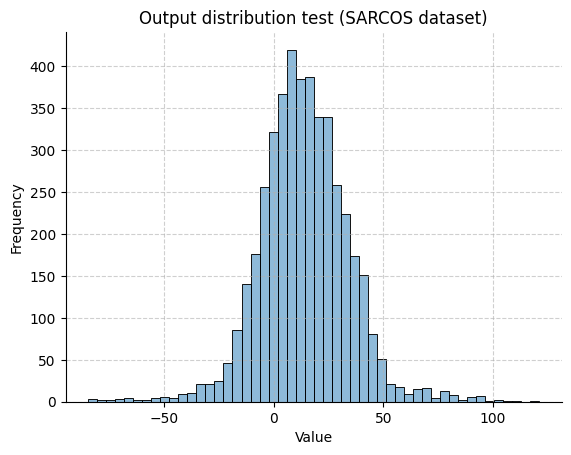

In [11]:
fig, ax = plt.subplots(ncols=1,nrows=1)
sns.histplot(y_test_sarcos, bins=50, ax=ax, legend=False)
ax.grid(linestyle="--", linewidth=0.8, alpha=0.6)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylabel("Frequency")
ax.set_xlabel("Value")
ax.set_title("Output distribution test (SARCOS dataset)")
fig.savefig("../definitive_plots/sarcos_dist_y_test.pdf")

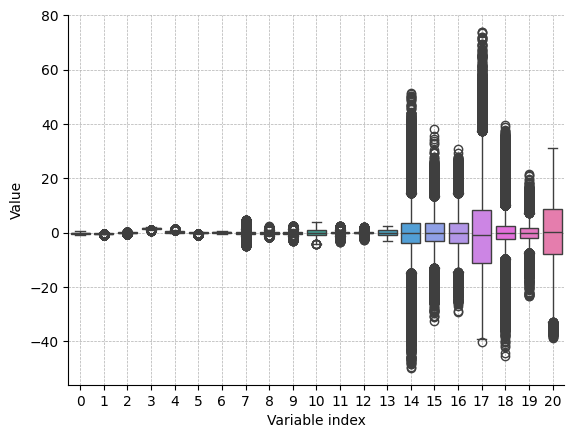

In [12]:
df_sarcos = pd.DataFrame(x_sarcos)
fig, ax = plt.subplots()
sns.boxplot(data=df_sarcos, ax=ax)
ax.set_xlabel("Variable index")
ax.set_ylabel("Value")
#ax.set_title("SARCOS input variables distribution")
ax.grid(linestyle="--", linewidth=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.savefig("../definitive_plots/sarcos_input_dist.pdf")
plt.show()

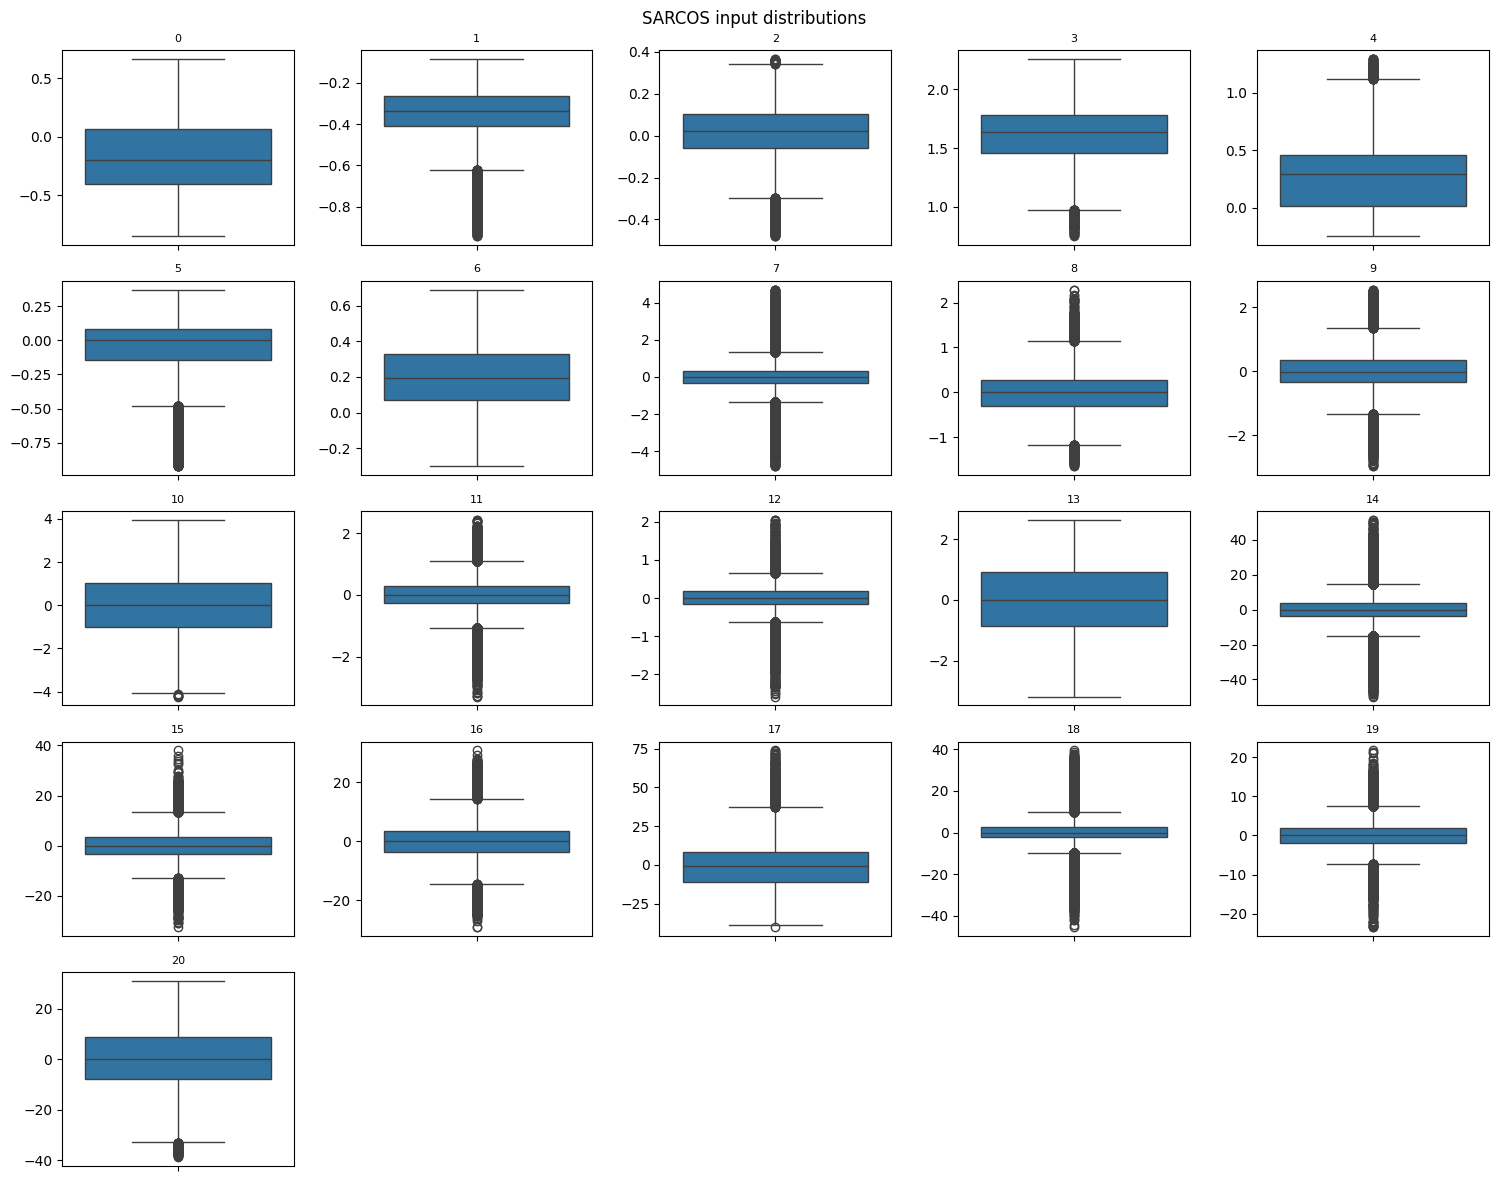

In [13]:
fig, ax = plt.subplots(5,5, figsize=(15,12))
ax = ax.flatten()

for i, col in enumerate(df_sarcos.columns):
    sns.boxplot(y=df_sarcos[col], ax=ax[i])
    ax[i].set_title(col, fontsize=8)
    ax[i].set_ylabel("")
for i in range(len(df_sarcos.columns), len(ax)):
    ax[i].set_visible(False)
fig.suptitle("SARCOS input distributions")
plt.tight_layout()
plt.show()
fig.savefig("../definitive_plots/sarcos_inputs_boxplots.pdf")

In [14]:
latex = df_sarcos.describe().T[["mean", "std", "min", "max", "25%","50%","75%"]].round(2).to_latex(caption="Statistical Summary inputs SARCOS dataset", 
                                                                                           label="tab:stats_sarcos", index=True, float_format="%.2f",
                                                                                           bold_rows=True, escape=True)
print(latex)

\begin{table}
\caption{Statistical Summary inputs SARCOS dataset}
\label{tab:stats_sarcos}
\begin{tabular}{lrrrrrrr}
\toprule
 & mean & std & min & max & 25\% & 50\% & 75\% \\
\midrule
\textbf{0} & -0.17 & 0.30 & -0.85 & 0.66 & -0.41 & -0.20 & 0.07 \\
\textbf{1} & -0.35 & 0.13 & -0.94 & -0.09 & -0.41 & -0.34 & -0.27 \\
\textbf{2} & 0.01 & 0.13 & -0.48 & 0.37 & -0.06 & 0.02 & 0.10 \\
\textbf{3} & 1.62 & 0.23 & 0.75 & 2.26 & 1.46 & 1.64 & 1.79 \\
\textbf{4} & 0.27 & 0.28 & -0.24 & 1.29 & 0.01 & 0.29 & 0.46 \\
\textbf{5} & -0.06 & 0.21 & -0.92 & 0.37 & -0.14 & 0.00 & 0.08 \\
\textbf{6} & 0.20 & 0.18 & -0.30 & 0.69 & 0.07 & 0.20 & 0.33 \\
\textbf{7} & 0.01 & 1.12 & -4.80 & 4.71 & -0.33 & -0.00 & 0.34 \\
\textbf{8} & -0.00 & 0.47 & -1.65 & 2.29 & -0.31 & 0.00 & 0.27 \\
\textbf{9} & -0.00 & 0.60 & -2.97 & 2.56 & -0.32 & -0.01 & 0.35 \\
\textbf{10} & -0.01 & 1.35 & -4.23 & 3.95 & -1.02 & 0.01 & 1.04 \\
\textbf{11} & 0.00 & 0.64 & -3.29 & 2.43 & -0.25 & 0.00 & 0.29 \\
\textbf{12} & -0.00 & 0.3

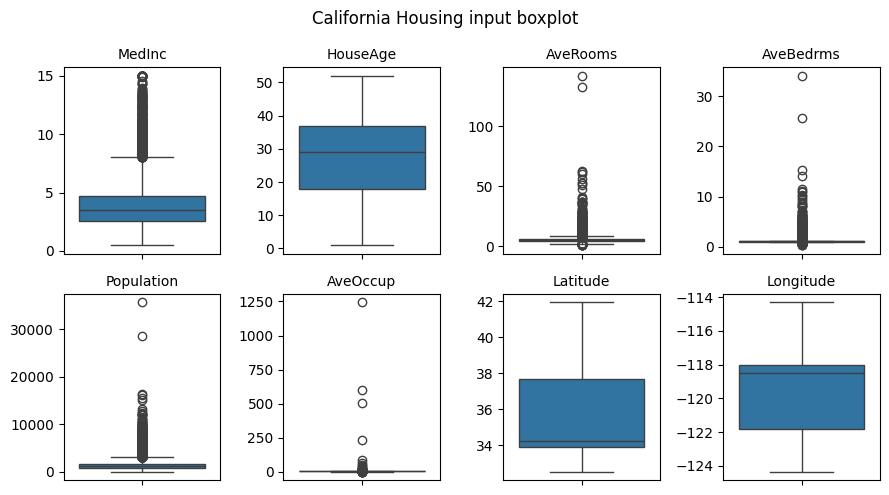

In [15]:
from sklearn.datasets import fetch_california_housing

housing_df = fetch_california_housing(as_frame=True)
housing_df = pd.DataFrame(housing_df["data"])

fig, ax = plt.subplots(2, 4, figsize=(9,5))
ax = ax.flatten()
for i, col in enumerate(housing_df.columns):
    sns.boxplot(y=housing_df[col], ax=ax[i])
    ax[i].set_title(col, fontsize=10)
    ax[i].set_ylabel("")
for i in range(len(housing_df.columns), len(ax)):
    ax[i].set_visible(False)
fig.suptitle("California Housing input boxplot")

plt.tight_layout()
plt.show()
fig.savefig("../definitive_plots/housing_boxplot_input.pdf")


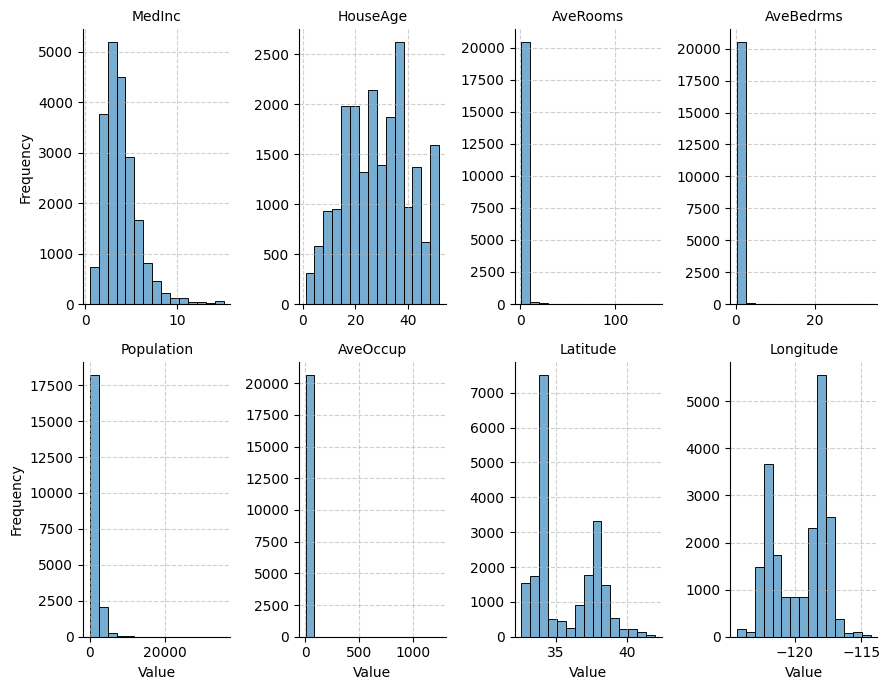

In [16]:
rows, cols = 2, 4
fig, ax = plt.subplots(rows, cols, figsize=(9,7))
ax = ax.flatten()

for i, col in enumerate(housing_df.columns):
    sns.histplot(data=housing_df[col], ax=ax[i], bins=15, alpha=0.6)
    ax[i].set_title(col, fontsize=10)
    ax[i].set_ylabel("")
    ax[i].set_xlabel("")
    ax[i].spines["top"].set_visible(False)
    ax[i].spines["right"].set_visible(False)
    ax[i].grid(linestyle="--", linewidth=0.8, alpha=0.6)

# Agregar títulos SOLO en los extremos
# Eje Y: primera columna de cada fila
for i in range(0, rows*cols, cols):  # i = 0, 4, 8,...
    ax[i].set_ylabel("Frequency")

# Eje X: última fila
for i in range((rows-1)*cols, rows*cols):  # última fila
    ax[i].set_xlabel("Value")

for i in range(len(housing_df.columns), len(ax)):
    ax[i].set_visible(False)

#fig.suptitle("California Housing input histogram")

plt.tight_layout()
plt.show()
fig.savefig("../definitive_plots/housing_histplot_input.pdf")


In [17]:
housing_df = fetch_california_housing(as_frame=True)
housing_df_target = housing_df["data"]

latex = housing_df_target.describe().T[["mean", "std", "min", "max", "25%","50%","75%"]].round(2).to_latex(caption="Statistical Summary target Housing dataset", 
                                                                                           label="tab:stats_housing_target", index=True, float_format="%.2f",
                                                                                           bold_rows=True, escape=True)
print(latex)

\begin{table}
\caption{Statistical Summary target Housing dataset}
\label{tab:stats_housing_target}
\begin{tabular}{lrrrrrrr}
\toprule
 & mean & std & min & max & 25\% & 50\% & 75\% \\
\midrule
\textbf{MedInc} & 3.87 & 1.90 & 0.50 & 15.00 & 2.56 & 3.53 & 4.74 \\
\textbf{HouseAge} & 28.64 & 12.59 & 1.00 & 52.00 & 18.00 & 29.00 & 37.00 \\
\textbf{AveRooms} & 5.43 & 2.47 & 0.85 & 141.91 & 4.44 & 5.23 & 6.05 \\
\textbf{AveBedrms} & 1.10 & 0.47 & 0.33 & 34.07 & 1.01 & 1.05 & 1.10 \\
\textbf{Population} & 1425.48 & 1132.46 & 3.00 & 35682.00 & 787.00 & 1166.00 & 1725.00 \\
\textbf{AveOccup} & 3.07 & 10.39 & 0.69 & 1243.33 & 2.43 & 2.82 & 3.28 \\
\textbf{Latitude} & 35.63 & 2.14 & 32.54 & 41.95 & 33.93 & 34.26 & 37.71 \\
\textbf{Longitude} & -119.57 & 2.00 & -124.35 & -114.31 & -121.80 & -118.49 & -118.01 \\
\bottomrule
\end{tabular}
\end{table}

